<center><span style="background-color: rgb(251, 160, 38); font-size: 32px;">  <b>NUCLIO DIGITAL SCHOOL -</b> MASTER EN DATA SCIENCE  </span></center>
    
<br>
    
<center><a href = https://nuclio.school/wp-content/uploads/2019/10/nucleoDS-newBlack.png > <img src="https://nuclio.school/wp-content/uploads/2019/10/nucleoDS-newBlack.png" width=400 height=100><a/></center>

<hr style="height:5px;border-width:0;color:orange;background-color:orange">
<center> <span style="font-size: 26px;">  Evolución de las ventas en Todo Ventas, S.A. </span> </center>

<span style="font-size: 12px;">


El objetivo del presente informe consiste en analizar la serie temporal de ventas facilitada con el fin de estimar el nivel de **ventas totales por país durante el próximo mes**. El dataset facilitado es una muestra representativa de las **ventas diarias por producto** en los mercados más importantes en los que opera la empresa *Todo Ventas, S.A.* 

La serie temporal disponible abarca, aproximadamente, un año. El horizonte de predicción considerado es de un mes, a partir de la última fecha disponible del conjunto de datos, es decir, el 9 de diciembre de 2023. 

Para alcanzar este objetivo, en primer lugar se realizará un análisis descriptivo sobre la serie temporal, con el fin de comprender la evolución de las ventas a lo largo del tiempo. Posteriormente, se desarrollarán distintos modelos, como Prophet y SARIMAX. Dichos modelos serán evaluados mediente métricas de error, como MAE, RMSE y MAPE, que permitirán analizar su capacidad predictiva. 

Finalmente se realizará una comparación de los modelos utilizados y se seleccionará aquel que ofrezca el mejor rendimiento y se realizarán las predicciones para lass ventas del próximo mes(desde el 9 de diciembre de 2023 hasta el 8 de enero de 2024). Estas predicciones servirán como apoyo para la toma de decisiones estratégicas de la empresa.

</span>

<br>

<hr style="height:5px;border-width:0;color:orange;background-color:orange">

## Indice
1. **Introducción y Preprocesamiento: análisis descriptivo.**      
        1.1. Énfasis en variables temporales y estacionalidad.   
        1.2. Análisis de autocorrelación y autocorrelación parcial.  
        1.3. Descomposición de los componenetes de la serie temporal. 

  2. **Desarrollo de Métodos.**  
        2.1. Prophet.   
        2.2. SARIMAX. 

  3. **Análisis de Resultados y Selección de Modelo.**   
        3.1. Comparación de modelos.  
        3.2. Selección de modelo basada en criterios y métricas. 

  4. **Conclusiones** 


# 1. INTRODUCCIÓN Y PREPROCESAMIENTO:
## 1.1. Énfasis en variables temporales y estacionalidad
 Análisis descriptivo.

In [979]:
## Carga de librerías:

# Base
import pandas as pd
import numpy as np

# Explorar el dataset (EDA)
import skimpy as sk

# Librerías de visualización 
import plotly.express as px
import matplotlib.pyplot as plt

# Manipular fechas
from datetime import datetime, timezone, time, timedelta, date

# Análisis de series temporales
from statsmodels.tsa.seasonal import seasonal_decompose # descomponer la serie en: tendencia + estacionalidad + ruido
from statsmodels.stats.diagnostic import het_white #heterocedasticidad: comprueba si la varianza cambia con el tiempo

# Modelo Arima
from pmdarima import auto_arima
from statsmodels.tsa.stattools import acf, pacf #para elegir parámetros de ARIMA
from statsmodels.tsa.stattools import adfuller # comprobar si una serie es estacionaria
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 
from statsmodels.tsa.arima.model import ARIMA, ARIMAResults
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Modelo Prophet
from prophet import Prophet
from prophet.plot import plot_cross_validation_metric, plot, plot_components 
from prophet.diagnostics import cross_validation, performance_metrics #validan el modelo

# para calculas métricas del modelo
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error

# utilidades varias
import warnings #ocultar avisos
warnings.filterwarnings("ignore")
warnings.filterwarnings('ignore', 'statsmodels.tsa.arima_model.ARMA', FutureWarning)

In [980]:
# Carga de los datasets:

df_prod = pd.read_csv("prod_dict.csv")
df_prod.head()

,StockCode,Description
0,10002,INFLATABLE POLITICAL GLOBE
1,10080,GROOVY CACTUS INFLATABLE
2,10120,DOGGY RUBBER
3,10125,MINI FUNKY DESIGN TAPES
4,10133,COLOURING PENCILS BROWN TUBE


In [981]:
df_retail= pd.read_csv("retail_todo_ventas.csv")
display(df_retail)

,InvoiceNo,StockCode,Date,Country,TotalSales
0,536365,21730,2022-12-01,United Kingdom,25.50
1,536365,22752,2022-12-01,United Kingdom,15.30
2,536365,71053,2022-12-01,United Kingdom,20.34
3,536365,84029E,2022-12-01,United Kingdom,20.34
4,536365,84029G,2022-12-01,United Kingdom,20.34
...,...,...,...,...,...
394325,581587,22730,2023-12-09,France,15.00
394326,581587,23254,2023-12-09,France,16.60
394327,581587,23255,2023-12-09,France,16.60
394328,581587,23256,2023-12-09,France,16.60


### Análisis exploratorio descriptivo

El análisis exploratorio ofrece una visión general sobre el conjunto de datos y ayuda a identificar patrones en la serie temporal (ventas). Este análisis permite identificar características relevantes (como patrones temporales/estacionales) que deberán tenerse en cuenta antes de construir los modelos predictivos. 

En las series temporales es importante comprender la estructura temporal de los datos, ya que elementos como, frecuencia de observación, presencia de estacionalidad o  existencia de valores faltantes pueden afectar significativamente al rendimiento de los modelos.

Por tanto, se analiza lo siguiente:
 - Presencia de valores nulos o vacíos.
 - Tipo de datos de cada variable (numéricas, categóricas o temporales).
 - Valores únicos en las variables.
 - Resumen estadístico general del conjunto de datos mediante la función *.skim()*.

Este proceso permite detectar posibles problemas en los datos y orientar las decisiones de preprocesamiento necesarias antes de aplicar los modelos de predicción.

In [982]:
# Revisar nulos en el dataset de retail:

df_retail.isnull().sum() # No hay valores nulos

InvoiceNo     0
StockCode     0
Date          0
Country       0
TotalSales    0
dtype: int64

In [983]:
# Revisar categorías:

df_retail.dtypes # Tenemos 4 categorías tipo objeto y TotalSales como numérico float.

InvoiceNo      object
StockCode      object
Date           object
Country        object
TotalSales    float64
dtype: object

In [984]:
# Cambio la categoría de Date: (porque está como 'object' y debería estar como 'Date'; para que el modelo interprete que es tiempo real)
df_retail["Date"] = pd.to_datetime(df_retail["Date"])

df_retail.dtypes  # Compruebo que el cambio de categoría lo ha hecho bien.

InvoiceNo             object
StockCode             object
Date          datetime64[ns]
Country               object
TotalSales           float64
dtype: object

In [985]:
# Revisar valores únicos:

df_retail.nunique() # en este Dataset vamos a analizar las ventas de 10 países.

InvoiceNo     19302
StockCode      3697
Date            305
Country          10
TotalSales     4937
dtype: int64

In [986]:
# Revisar el rango de fechas del dataset completo (todos los países):

print(f'La serie temporal (de los 10 países) empieza el {df_retail["Date"].min()} y termina el {df_retail["Date"].max()}.')

La serie temporal (de los 10 países) empieza el 2022-12-01 00:00:00 y termina el 2023-12-09 00:00:00.


In [987]:
# Revisar si faltan datos en el dataset completo - Análisis con todos los países:

# Fechas del dataset 
print(f'Las fechas originales del dataset son: {len(df_retail["Date"].unique())} días')

# Creo la secuencia de fechas esperadas
full_dates_0 = pd.date_range(
start=df_retail["Date"].min(),
    end=df_retail["Date"].max(),
    freq="D"
)
print(f'Las fechas esperadas de la serie temporal a analizar son: {len(full_dates_0)} días')

# Devuelve las fechas que faltan 
missing_dates_0 = full_dates_0.difference(df_retail["Date"].unique())
print(f'Faltan: {len(missing_dates_0)} días para que el dataset esté completo')

Las fechas originales del dataset son: 305 días
Las fechas esperadas de la serie temporal a analizar son: 374 días
Faltan: 69 días para que el dataset esté completo


In [988]:
# Analizamos los días que faltan por día de la semana: 

missing_dates_0.day_name().value_counts()

Sunday       53
Tuesday       6
Saturday      4
Monday        3
Wednesday     1
Thursday      1
Friday        1
Name: count, dtype: int64

En primer lugar, se analiza la **continuidad de las fechas a nivel global** para comprender la estructura temporal general del dataset y detectar posibles fechas sin registros o interrupciones en la serie temporal. Como conclusiones de este análisis podemos destacar lo siguiente:

- El dataset empieza el 1 de diciembre de 2022 y termina el 9 de diciembre de 2023. Si se considera una frecuencia diaria, deberíamos tener 374 fechas. Sin embargo, únicamente tenemos 305 fechas distintas, lo que indica la **ausencia de 69 días en la serie temporal**. 

- Gran parte de las fechas faltantes se corresponde a los **domingos**, lo que sugiere que las ventas no se registran ese día o que la actividad comercial es inexistente. 

Este comportamiento sugiere la presencia de un patrón semanal en la serie temporal, aspecto que deberá tenerse en cuenta para el desarrollo de los modelos.

In [989]:
# Revisar el rango de fechas de CADA país:

for country in df_retail["Country"].unique():

    df_country = df_retail[df_retail["Country"] == country]

    # rango real de fechas para ese país
    full_dates = pd.date_range(
        start=df_country["Date"].min(),
        end=df_country["Date"].max(),
        freq="D"
    )

    # fechas registradas
    real_dates = df_country["Date"].unique()

    # fechas faltantes
    missing_dates = full_dates.difference(real_dates)

    print(f'La serie de {country} empieza el {df_country["Date"].min()} y termina el {df_country["Date"].max()}.')
    print(f'Faltan: {len(missing_dates)} días para que la serie temporal de {country} esté completa.')
    print(f'Ejemplo de algunas fechas que faltan: {missing_dates[:5]}')
    print(  )


La serie de United Kingdom empieza el 2022-12-01 00:00:00 y termina el 2023-12-09 00:00:00.
Faltan: 69 días para que la serie temporal de United Kingdom esté completa.
Ejemplo de algunas fechas que faltan: DatetimeIndex(['2022-12-04', '2022-12-11', '2022-12-18', '2022-12-24',
               '2022-12-25'],
              dtype='datetime64[ns]', freq=None)

La serie de France empieza el 2022-12-01 00:00:00 y termina el 2023-12-09 00:00:00.
Faltan: 168 días para que la serie temporal de France esté completa.
Ejemplo de algunas fechas que faltan: DatetimeIndex(['2022-12-02', '2022-12-04', '2022-12-06', '2022-12-11',
               '2022-12-12'],
              dtype='datetime64[ns]', freq=None)

La serie de Netherlands empieza el 2022-12-01 00:00:00 y termina el 2023-12-07 00:00:00.
Faltan: 311 días para que la serie temporal de Netherlands esté completa.
Ejemplo de algunas fechas que faltan: DatetimeIndex(['2022-12-02', '2022-12-03', '2022-12-04', '2022-12-05',
               '2022-12-06'],

En segundo lugar, se analiza la **continuidad de las fechas por país** para identificar posibles diferencias. Este análisis resulta necesario porque el objetivo del estudio es predecir las ventas totales por país, por lo que cada país debe tratarse como una serie temporal independiente con su propio comportamiento. Como conclusiones del análisis anterior podemos decir que:

- No todos los países presentan el mismo nivel de continuidad en la serie temporal. El más completo es Reino Unido, cuya serie temporal comienza el 1 de diciembre de 2022 y finaliza el 9 de diciembre de 2023, presentando únicamente 69 fechas vacías. La mayoría de estas fechas se corresponden a domingos, lo que refuerza la hipótesis de la existencia de un patrón semanal en las ventas. 

- En contraste, otros países presentan un número mayor de fechas vacías, como Portugal, Italia o Suecia. Esto sugiere que las ventas en estos países son más esporádicas o presentan un volcado de datos con menos frecuencia que Reino Unido. Por ejemplo: España comienza el 3 de diciembre de 2022 y mantiene un patrón similar al de Reino Unido, con datos principalmente de lunes a sábado. Sin embargo, países como Suecia o Portugal presentan largos periodos sin registros, lo que evidencia una serie temporal mucho más irregular.

Estas diferencias indican que los mercados no se comportan de las misma forma, lo que puede afectar al comportamiento del modelo. Entre los países analizados, **Reino Unido presenta una serie temporal más completa (y mayor volumen de ventas), por lo que será el que utilice para los modelos**. El resto de países, pueden utilizarse como series adicionales para contrastar el comportamiento del modelo.

In [990]:
sk.skim(df_retail)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 394330 │ │ string      │ 2     │                                                          │
│ │ Number of columns │ 4      │ │ datetime64  │ 1     │                                                          │
│ └───────────────────┴────────┘ │ float64     │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column         ┃ NA   ┃ NA %   ┃ mean     ┃ sd       ┃ p0   ┃ p25    ┃ p50     ┃ p75    ┃ p100   ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩  │
│ │ TotalSales     │    0 │      0 │    24.49 │    103.7 │    0 │   7.38 │   13.52 │   19.9 │  38970 │    █    │  │
│ └────────────────┴──────┴────────┴──────────┴──────────┴──────┴────────┴─────────┴────────┴────────┴─────────┘  │
│                                                    datetime                                                     │
│ ┏━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column         ┃ NA     ┃ NA %       ┃ first                 ┃ last                  ┃ frequency           ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩  │
│ │ Date           │      0 │          0 │      2022-12-01       │      2023-12-09       │ None                │  │
│ └────────────────┴────────┴────────────┴───────────────────────┴───────────────────────┴─────────────────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃          ┃            ┃         ┃            ┃ chars per  ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest ┃ longest    ┃ min     ┃ max        ┃ row        ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ StockCode │  0 │    0 │ M        │ BANK       │ 10002   │ S          │       5.08 │         1 │     394341 │  │
│ │           │    │      │          │ CHARGES    │         │            │            │           │            │  │
│ │ Country   │  0 │    0 │ EIRE     │ United     │ Belgium │ United     │       13.5 │       1.9 │     761655 │  │
│ │           │    │      │          │ Kingdom    │         │ Kingdom    │            │           │            │  │
│ └───────────┴────┴──────┴──────────┴────────────┴─────────┴────────────┴────────────┴───────────┴────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

Finalmente, se realiza un resumen con Skim, que permite obtener una vision general de la estructura de los datos. Se puede observar que las variables están correcctamente en su categoría: *TotalSales* es numérica, la columna *Date* se corresponde con las fechas de la serie, y el resto (StockCode, Country) son de tipo string. 

- Observamos que no hay valores nulos.

- Observamos la media de *TotalSales* de: 24.49. El mes con menos ventas hubo 0 mientras que mes con más ventas hubo 38970.


In [991]:
display(df_retail)

,InvoiceNo,StockCode,Date,Country,TotalSales
0,536365,21730,2022-12-01,United Kingdom,25.50
1,536365,22752,2022-12-01,United Kingdom,15.30
2,536365,71053,2022-12-01,United Kingdom,20.34
3,536365,84029E,2022-12-01,United Kingdom,20.34
4,536365,84029G,2022-12-01,United Kingdom,20.34
...,...,...,...,...,...
394325,581587,22730,2023-12-09,France,15.00
394326,581587,23254,2023-12-09,France,16.60
394327,581587,23255,2023-12-09,France,16.60
394328,581587,23256,2023-12-09,France,16.60


### Preprocesamiento

Una vez analizada la estructura del dataset, se procede a **agrupar las ventas por fecha y país** con el objetivo de obtener las ventas totales diarias de cada mercado. 

Posteriormente, ese dataset se divide en varias **series temporales independientes, una para cada país**. Esta separación es necesaria para predecir las ventas por país, ya que los modelos que se van a utilizar (Prophet y SARIMAX) trabajan con una única serie temporal por modelo.

In [ ]:
# Agrupo por fecha y país (para obtener las ventas totales diarias de cada país) 

df_paises = df_retail.groupby(["Date", "Country"])["TotalSales"].sum().reset_index()

In [993]:
# Compruebo que realmente el dataset está ordenado cronológicamente.

df_paises.index.is_monotonic_increasing 

True

In [994]:
# Selecciono del df_paises los países

df_be = df_paises[df_paises["Country"]=="Belgium"]
df_ie = df_paises[df_paises["Country"]=="EIRE"] #Irlanda
df_fr = df_paises[df_paises["Country"]=="France"]
df_de = df_paises[df_paises["Country"]=="Germany"]
df_it = df_paises[df_paises["Country"]=="Italy"]
df_nl = df_paises[df_paises["Country"]=="Netherlands"]
df_pt = df_paises[df_paises["Country"]=="Portugal"]
df_es = df_paises[df_paises["Country"]=="Spain"]
df_se = df_paises[df_paises["Country"]=="Sweden"]
df_uk = df_paises[df_paises["Country"]=="United Kingdom"]

In [995]:
display(df_be) # Bélgica

,Date,Country,TotalSales
8,2022-12-03,Belgium,304.90
52,2022-12-17,Belgium,579.54
67,2022-12-21,Belgium,211.03
73,2022-12-22,Belgium,519.60
101,2023-01-12,Belgium,578.08
...,...,...,...
1120,2023-11-22,Belgium,301.25
1151,2023-11-29,Belgium,239.40
1165,2023-12-02,Belgium,295.20
1180,2023-12-06,Belgium,771.11


In [996]:
display(df_ie) # Irlanda

,Date,Country,TotalSales
0,2022-12-01,EIRE,483.08
5,2022-12-02,EIRE,22.50
9,2022-12-03,EIRE,2342.24
19,2022-12-06,EIRE,1043.45
30,2022-12-09,EIRE,854.35
...,...,...,...
1161,2023-12-01,EIRE,932.46
1170,2023-12-04,EIRE,726.46
1174,2023-12-05,EIRE,527.10
1186,2023-12-07,EIRE,3468.35


In [997]:
display(df_fr) # Francia

,Date,Country,TotalSales
1,2022-12-01,France,792.90
10,2022-12-03,France,371.40
16,2022-12-05,France,1416.10
23,2022-12-07,France,1320.88
26,2022-12-08,France,142.05
...,...,...,...
1175,2023-12-05,France,727.96
1181,2023-12-06,France,1277.32
1187,2023-12-07,France,1032.42
1194,2023-12-08,France,165.90


In [998]:
display(df_de) # Alemania

,Date,Country,TotalSales
2,2022-12-01,Germany,261.48
6,2022-12-02,Germany,145.40
11,2022-12-03,Germany,475.78
17,2022-12-05,Germany,2394.97
20,2022-12-06,Germany,182.84
...,...,...,...
1172,2023-12-04,Germany,1063.73
1176,2023-12-05,Germany,263.79
1188,2023-12-07,Germany,2696.50
1195,2023-12-08,Germany,1178.84


In [999]:
display(df_it) # Italia

,Date,Country,TotalSales
12,2022-12-03,Italy,354.70
70,2022-12-21,Italy,333.45
106,2023-01-13,Italy,1397.26
132,2023-01-21,Italy,313.10
148,2023-01-26,Italy,433.00
215,2023-02-18,Italy,194.50
253,2023-03-04,Italy,390.08
288,2023-03-17,Italy,896.48
326,2023-03-28,Italy,293.50
359,2023-04-07,Italy,412.56


In [1000]:
display(df_nl) # Países Bajos

,Date,Country,TotalSales
3,2022-12-01,Netherlands,177.60
65,2022-12-20,Netherlands,64.36
71,2022-12-21,Netherlands,7831.24
111,2023-01-14,Netherlands,9659.02
124,2023-01-19,Netherlands,7123.28
...,...,...,...
1110,2023-11-20,Netherlands,148.16
1125,2023-11-22,Netherlands,784.44
1132,2023-11-23,Netherlands,9101.74
1159,2023-11-30,Netherlands,104.00


In [1001]:
display(df_pt) # Portugal 

,Date,Country,TotalSales
13,2022-12-03,Portugal,101.80
21,2022-12-06,Portugal,117.70
28,2022-12-08,Portugal,1060.40
33,2022-12-09,Portugal,229.10
39,2022-12-10,Portugal,249.95
56,2022-12-17,Portugal,444.90
91,2023-01-09,Portugal,974.52
119,2023-01-18,Portugal,2146.90
149,2023-01-26,Portugal,600.48
223,2023-02-21,Portugal,853.08


In [1002]:
display(df_es) # España

,Date,Country,TotalSales
14,2022-12-03,Spain,521.00
34,2022-12-09,Spain,162.45
43,2022-12-13,Spain,850.77
57,2022-12-17,Spain,130.50
87,2023-01-07,Spain,1036.40
...,...,...,...
1133,2023-11-23,Spain,2720.00
1139,2023-11-24,Spain,151.54
1154,2023-11-29,Spain,164.44
1184,2023-12-06,Spain,159.58


In [1003]:
display(df_se) # Suecia 

,Date,Country,TotalSales
45,2022-12-14,Sweden,1188.00
58,2022-12-17,Sweden,2536.20
79,2023-01-04,Sweden,538.44
156,2023-01-28,Sweden,2672.00
168,2023-02-01,Sweden,478.00
265,2023-03-10,Sweden,122.40
277,2023-03-14,Sweden,4258.08
313,2023-03-24,Sweden,169.70
378,2023-04-15,Sweden,443.20
401,2023-04-27,Sweden,292.70


In [1004]:
display(df_uk) # Reino Unido

,Date,Country,TotalSales
4,2022-12-01,United Kingdom,53520.58
7,2022-12-02,United Kingdom,46422.64
15,2022-12-03,United Kingdom,40483.46
18,2022-12-05,United Kingdom,25018.63
22,2022-12-06,United Kingdom,51731.61
...,...,...,...
1179,2023-12-05,United Kingdom,83274.82
1185,2023-12-06,United Kingdom,51767.13
1192,2023-12-07,United Kingdom,54270.50
1196,2023-12-08,United Kingdom,77242.10


### Evoluación temporal de las ventas por país
A continuación, se representan las series temporales de ventas para los distintos países con el objetivo de analizar su evolución a lo largo del tiempo. El gráfico se presenta ordenado según el número de ventas, por lo que Reino Unido aparecerá en primer lugar.

El análisis de estos gráficos permite identificar posibles tendencias, patrones de estacionalidad y variaciones en el volumen de ventas, así como detectar picos de demanda o comportamientos atípicos en determinados periodos, que pueden corresponderse con vacaciones o eventos importantes en el país.

In [1005]:
# Orden de países por ventas totales (de mayor a menor)
country_order = (df_paises.groupby("Country")["TotalSales"].sum().sort_values(ascending=False).index.tolist())

# Grafico los paises ordenados según sus ventas.
fig = px.line(
    df_paises,
    x="Date",
    y="TotalSales",
    color="Country",
    category_orders={"Country": country_order},
    title="Ventas diarias por país",
    facet_row="Country",
    height=1500
).update_yaxes(matches=None)

fig.show()

- Reino Unido concentra un volumen de ventas significativamente mayor y presenta una serie temporal más completa y regular que el resto de países. 

- Los niveles de ventas del resto de países rara vez superan los 10.000 (a excepción de Países Bajos), frente a los picos de Reino Unido, que oscilan entre 50.000 y 100.000. Además, como se ha comentado antes, estas series son más irregulares.

Por estos motivos, **Reino Unido se utilizará como serie principal para el análisis y el desarrollo de los modelos de predicción**.

### Evoluación temporal de las ventas en Reino Unido

In [1006]:
# Gráfico de la serie temporal 

serie_paises = df_uk.set_index("Date")["TotalSales"]

fig = px.line(df_uk, x="Date",y="TotalSales", title="Ventas diarias en United Kingdom", labels={"Date": "Fecha", "TotalSales": "Ventas"})
fig.show()

Una serie temporal se descompone en cuatro elementos: tendencia, estacionalidad, componente cíclico y ruido. En el caso de Reino Unido se observa que:
- **Tendencia:** 
    - Caida inicial: tras el pico inicial registrado el 7 de diciembre de 2022 (95.700), se observa una tendencia descendente hasta principios de enero de 2023. 
    - Periodo estable: desde enero de 2023 hasta finales de verano la tendencia es relativamente constante. 
    - Crecimiento final: a partir de mediamos de julio, ser observa una tendecia positiva más marcada, y que continúa hasta el final de la serie temporal. 
    Este comportamiento podría estar relacionado con periodos de mayor actividad (a partir del verano y hasta finales de año) y periodos de menor actividad, puede deberse según el tipo de producto que venda esta empresa. Además, se observan picos puntuales de ventas que podrían corresponder a campañas comerciales o eventos específicos.
- **Estacionalidad:** la serie presenta estacionalidad porque se observan fluctuaciones recurrentes, con incrementos y descensos a lo largo del tiempo. Estas variaciones podrían estar relacionadas con la dinámica semanal de las transacciones, donde quizás, ciertos días presentan una mayor actividad que otros, mientras que los domingos no registran ventas. 
- **Componente cíclico:** no se observa de forma clara un componente cíclico en esta serie temporal. Este tipo de fluctuaciones suelen estar asociadas a ciclos de mayor duración y en este caso solo tenemos 1 año de datos.
- **Ruido:** es la variabilidad no explicable por el modelo. En este caso puede deberse a factores aleatorios como ciertas promociones puntuales o cambios en la demanda o eventos específicos. 

### Distribución de las ventas por mes en Reino Unido
Para analizar la distribución de las ventas a lo largo del año se representa un boxplot por mes. Este tipo de gráficos permite tanto la dispersión de las ventas, la mediana de cada mes como detectar posibles valores atípicos.

In [1007]:
# Creo la columna mes
df_uk['month_name'] = df_uk['Date'].dt.month_name()

# Agrupa por mes
mes_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October','November','December']
df_uk['month_name'] = pd.Categorical(df_uk['month_name'] , categories=mes_order, ordered=True)

# Gráfico de boxplot
fig = px.box(df_uk, x='month_name', y='TotalSales', labels={'month_name': 'Month', 'TotalSales': 'TotalSales'}, title = 'Ventas por mes en Reino Unido')
fig.show()

En el gráfico se identifican algunos valores atípicos (y/o picos de ventas), sobre todo en los meses de agosto, septiembre y noviembre. Estos valores atípicos, representados por puntos fuera de los bigotes del diagrama, indican días con ventas muy superiores al comportamiento habitual del mes. Estos picos pueden sugerir que en esos días hubo promociones o eventos específicos que generaron muchas ventas. 

### Distribución de las ventas por día en Reino Unido
Una vez analizadas las ventas por mes, se estudia la distribución de las ventas por día de la semana. Este análisis permite identificar posibles diferencias en el volumen de ventas entre los distintos días, lo que puede ayudar a detectar patrones semanales.

In [1008]:
# Establezo el orden de la serie de los días dde la semana:
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

# Extraigo el día
df_uk["weekday"] = pd.Categorical(df_uk["Date"].dt.day_name(),categories=weekday_order,ordered=True)

# Agrupo por el nombre del día y el total de las ventas
ventas_semana_uk = df_uk.groupby("weekday")["TotalSales"].mean()

# Gráfico de barras
px.bar(ventas_semana_uk, x = ventas_semana_uk.index, y = 'TotalSales', text = 'TotalSales',  title = 'Ventas totales (media) por día de la semana - UK') # los domingos no hay datos, no hay ventas. # el máximo es el miércoles.

A partir del gráfico se puede observar que:
- Los domingos no se registran ventas. 
- Se observan diferencias entre unos días y otros de la semana.
    - El lunes es el día con menos ventas, seguido del jueves.
    - El miércoles el día con más ventas, seguido del viernes y martes. 

Estas diferencias sugieren la **presencia de un patron semanal** en las ventas. 

## 1.2. Análisis de autocorrelación y autocorrelación parcial. 
Una vez analizados los patrones generales de la serie temporal, se analiza la autocorrelación y autocorrelación parcial de la serie para identificar posibles dependencias entre observaciones separadas en el tiempo.
 - **Autocorrelación (ACF):** mide la correlación de Pearson entre la serie y los valores anteriores. Permite identificar si los valores actuales están relacionados con observaciones pasadas. 
    - Como interpretarlo: la zona sombreada en azul indica el intervalo de confianza y las barras azules la autocorrelación en cada lag. Si una barra se sale fuera del intervalo, significa que esa autocorrelación es estadísticamente significativa. 

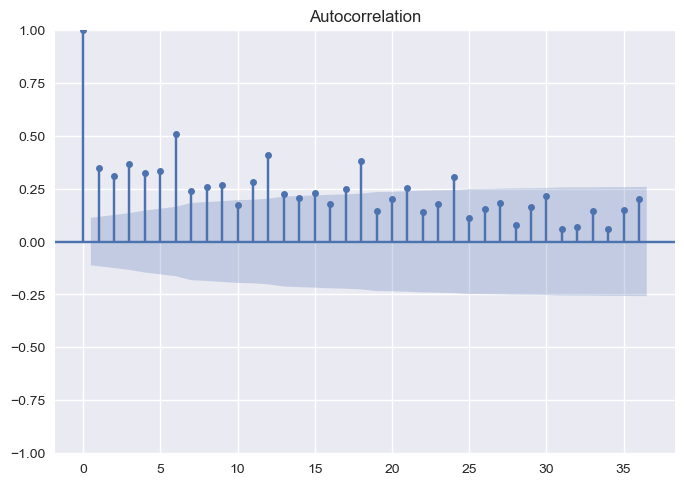

In [1009]:
# Calcular la autocorrelación para un lag específico con pandas:
df_uk['TotalSales'].autocorr(lag=1)

# Calcular la autocorrelación hasta un lag máximo
autocorr_values = acf(df_uk['TotalSales'], nlags=36)

# Gráfico de autocorrelación (ACF)
plot_acf(df_uk['TotalSales'], lags = 36)
plt.show()

Sobre la autocorrelación:
Se puede observar autocorrelaciones significativas en los primeros puntos: 1-9, lo que indica que las ventas están relacionadas con los días anteriores. 
Se identidican algunos picos en 11, 12, 18 y 24, lo que puede indicar la existencia de dependencias temporales además de las de corto plazo.

 - **Autocorrelación parcial (PACF):** mide la relación entre un valor de la serie y los valores anterioes eliminando la serie "retrasada". 

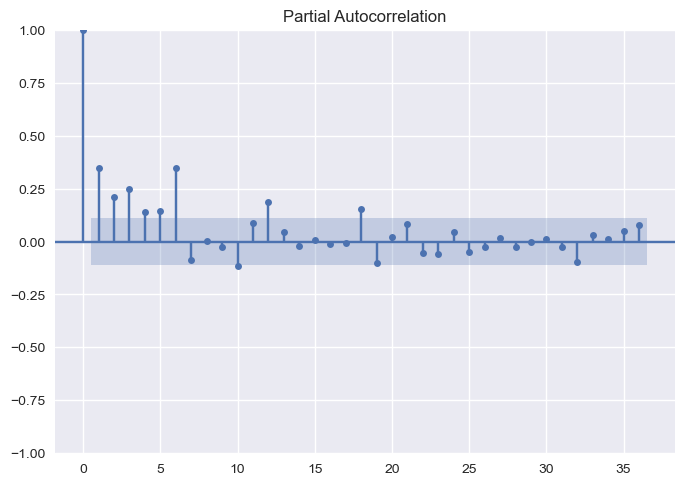

In [1010]:
# Calcular la autocorrelación parcial hasta un lag máximo
pautocorr_values = pacf(df_uk['TotalSales'], nlags=36)
plot_pacf(df_uk['TotalSales'], lags = 36)
plt.show()

Sobre la autocorrelación parcial: se observan picos significativos en los primeros puntos, lo que indica que las ventas actuales están directamente influenciadas por las ventas registradas en los días anteriores.También se observan picos en el punto 12 y 18, lo que parece indicar que existe un patrón semanal en las ventas.

## 1.3. Descomposición de los componentes de la serie temporal.
A continuación, se realiza una descomposición de la serie en sus componentes principales: tendencia, estacionalidad y ruido. Este proceso permite separar la serie observada en diferentes partes que explican su comportamiento a lo largo del tiempo, lo que facilita la **identificación de patrones** que pueden ser relevantes para el desarrollo de los modelos.

### Modelo aditivo
Un modelo aditivo es lineal  $y(t) = Nivel + Tendencia + Estacionalidad + Ruido$

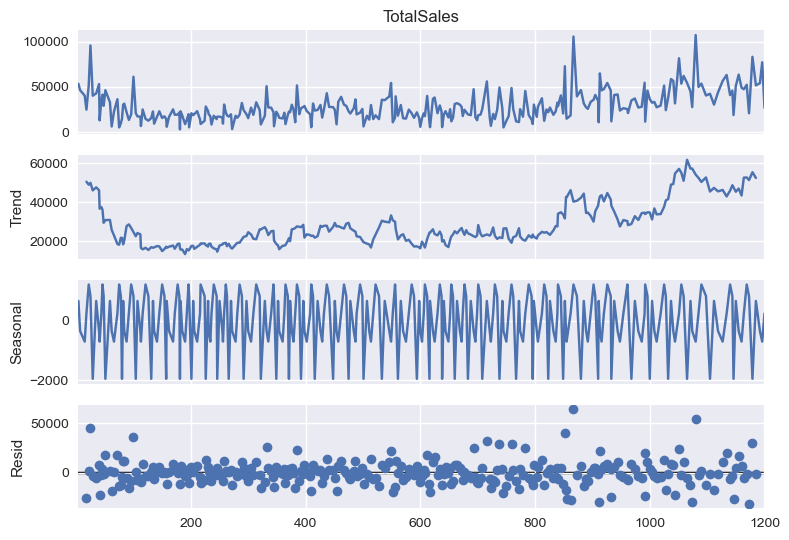

In [1011]:
result = seasonal_decompose(df_uk['TotalSales'], model = 'additive', period = 7) # periodo 7 días
result.plot()
plt.show()

- El primer gráfico muestra la serie original de ventas diarias en Reino Unido, que refleja la evolución completa de las ventas a lo largo del periodo analizado. Esta gráfica se corresponde a la suma de las siguientes tres: tendencia + estacionalidad + ruido.  

    - **Gráfico tendencia (Trend):** se observa una caída inicial durante diciembre de 2022 y principios de enero de 2023. Posteriormente, la serie muestra un periodo relativamente estable con una ligera tendencia positiva, para finalmente presentar un crecimiento más marcado a partir de septiembre de 2023, que continúa hasta el final de la serie.  

    - **Gráfico estacionalidad (Seasonal):** se identifica un patrón que se repite semanalmente. En este patrón se observa que los domingos las ventas son 0, tras lo cual aumentan el lunes, disminuyen ligeramente el martes y alcanzan su máximo alrededor del miércoles, antes de volver a descender hacia el final de la semana.  
    
    - **Gráfico residuo (Residual):** es el ruido de la serie, es decir, el componente residual que no puede explicarse con la tendencia o estacionalidad. 

### Modelo multiplicativo
El modelo multiplicativo no es lineal:  $y(t) = Nivel * Tendencia * Estacionalidad *  Ruido$

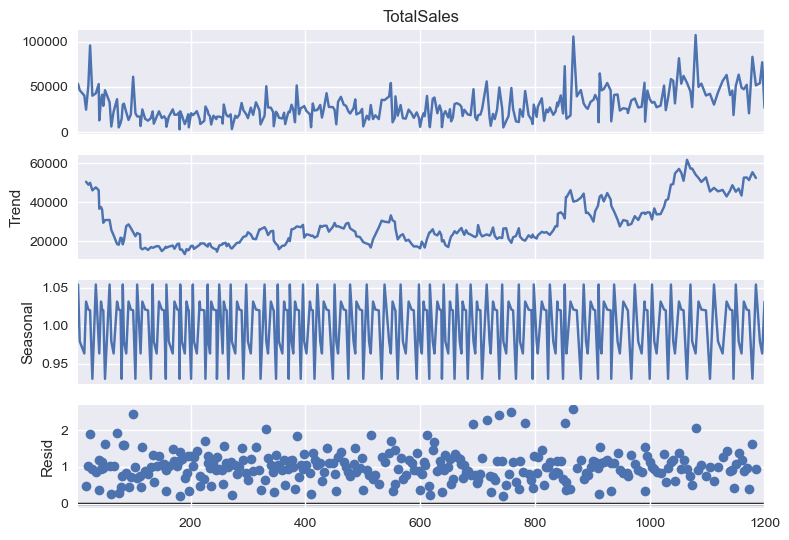

In [1012]:
result = seasonal_decompose(df_uk['TotalSales'], model = 'multiplicative', period = 7)
result.plot()
plt.show()

Además de la descomposición aditiva, se realiza también una descomposición multiplicativa para analizar si la estacionalidad de la serie depende del nivel de las ventas.
En el modelo multiplicativo la estacionalidad se interpreta en porcentaje, no en suma. Por ejemplo, valores  igual a 1.05 indica que la estacionalidad aumenta un 5% (*1.05), mientras que si son valores igual a 0.95, indica que la estacionalidad disminuye un x.0.95, es decir, disminuye un 5%.

## 1.4. Preparar datos para el modelo:
- Completar las fechas faltantes:

In [1013]:
# Completo las fechas que faltan (domingos sobre todo) con ventas = 0, porque los domingos no hubo ventas
all_dates = pd.date_range(df_uk["Date"].min(),
                          df_uk["Date"].max(),
                          freq="D")

df_uk_full = df_uk.set_index("Date").reindex(all_dates)

df_uk_full["TotalSales"] = df_uk_full["TotalSales"].fillna(0) # Añade 0 a las fechas faltantantes

df_uk_full = df_uk_full.reset_index().rename(columns={"index":"Date"}) # Índice reset

#Completo el dataset
df_uk_full["Country"] = "United Kingdom"
df_uk_full["month_name"] = df_uk_full["Date"].dt.month_name()
df_uk_full["weekday"] = df_uk_full["Date"].dt.day_name()

df_uk = df_uk_full
display(df_uk) # compruebo que ha añadido lo anterior.

,Date,Country,TotalSales,month_name,weekday
0,2022-12-01,United Kingdom,53520.58,December,Thursday
1,2022-12-02,United Kingdom,46422.64,December,Friday
2,2022-12-03,United Kingdom,40483.46,December,Saturday
3,2022-12-04,United Kingdom,0.00,December,Sunday
4,2022-12-05,United Kingdom,25018.63,December,Monday
...,...,...,...,...,...
369,2023-12-05,United Kingdom,83274.82,December,Tuesday
370,2023-12-06,United Kingdom,51767.13,December,Wednesday
371,2023-12-07,United Kingdom,54270.50,December,Thursday
372,2023-12-08,United Kingdom,77242.10,December,Friday


- Preparo los datos para el modelo Prophet: creo las columnas DS e Y

In [1014]:
df_prophet_uk = df_uk[['Date','TotalSales']].rename(columns={'Date':'ds','TotalSales':'y'})
df_prophet_uk.head()

,ds,y
0,2022-12-01,53520.58
1,2022-12-02,46422.64
2,2022-12-03,40483.46
3,2022-12-04,0.00
4,2022-12-05,25018.63


- División en Train / Test

In [1015]:
train_df_uk = df_prophet_uk[:-30] # todo el dataset de entrenamientos menos los últimos 30 días
test_df_uk = df_prophet_uk[-30:] # selecciono los últimos 30 días para test

train_df_uk # Compruebo las fechas

,ds,y
0,2022-12-01,53520.58
1,2022-12-02,46422.64
2,2022-12-03,40483.46
3,2022-12-04,0.00
4,2022-12-05,25018.63
...,...,...
339,2023-11-05,0.00
340,2023-11-06,31932.09
341,2023-11-07,81664.45
342,2023-11-08,53680.47


In [1016]:
test_df_uk.shape # compruebo que hay 30 días 

(30, 2)

In [1017]:
test_df_uk.head() # compruebo que las fechas empiezan en 2023-11-04 

,ds,y
344,2023-11-10,54518.61
345,2023-11-11,45096.33
346,2023-11-12,0.00
347,2023-11-13,27838.14
348,2023-11-14,107229.10


In [1018]:
test_df_uk.tail() # compruebo que las fechas terminan el 2023-12-09.

,ds,y
369,2023-12-05,83274.82
370,2023-12-06,51767.13
371,2023-12-07,54270.50
372,2023-12-08,77242.10
373,2023-12-09,26956.27


# 2. DESARROLLO DE MÉTODOS
## 2.1. PROPHET

Prophet es un procedimiento de predicción de datos de series temporales basado en un modelo aditivo en el que se ajustan las tendencias no lineales para la estacionalidad anual, semanal y diaria, además de los efectos de días festivos. Funciona mejor con series temporales que tienen efectos estacionales fuertes (ya sean semanales o mensuales) y una cantidad suficiente de datos históricos donde se representa esa estacionalidad. **Prophet es robusto ante datos faltantes** y cambios de tendencia, y tiende a manejar bien los valores atípicos.

Los datos de entrada para Prophet siempre siguen el mismo formato con dos columnas: `ds` e `y`.
- La columna `ds` (fecha o marca de tiempo) debe estar en el formato esperado por Pandas, idealmente YYYY-MM-DD para una fecha o YYYY-MM-DD HH:MM:SS para una marca de tiempo.
- La columna `y` debe ser numérica y representa el valor que queremos pronosticar.

### 2.1.1. Entrenamiento de modelo Prophet, predicción con test.
A continuación vamos a utilizar el modelo Prophet y lo vamos a entrenar con los datos de Train, para después intentar predecir en Test (2023-11-04 hasta 2023-12-09). Después de ello, analizaremos este modelo utilizando métricas de error para analizar su capacidad predictiva.

In [1019]:
# Entrenar el modelo Prophet
model_p_uk = Prophet(weekly_seasonality=True, daily_seasonality=False)
model_p_uk.fit(train_df_uk)

23:57:00 - cmdstanpy - INFO - Chain [1] start processing
23:57:00 - cmdstanpy - INFO - Chain [1] done processing


In [1020]:
# Proyectar a un mes vista, a partir de test

future_p_uk = model_p_uk.make_future_dataframe(periods=len(test_df_uk)+30,freq='D') # predecir 1 mes más
future_p_uk

,ds
0,2022-12-01
1,2022-12-02
2,2022-12-03
3,2022-12-04
4,2022-12-05
...,...
399,2024-01-04
400,2024-01-05
401,2024-01-06
402,2024-01-07


In [1021]:
# Generar las predicciones: ds = fecha, yhat = dicción, yhat_lower = límite inferior, yhat_upper = límite superior.
forecast_p_uk = model_p_uk.predict(future_p_uk)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

display(forecast_p_uk.head(5))
display(forecast_p_uk.tail(5))

,ds,yhat,yhat_lower,yhat_upper
0,2022-12-01,23125.938149,8393.245916,38794.759095
1,2022-12-02,27955.735459,12153.593023,43742.910686
2,2022-12-03,21076.520532,6483.281117,36321.031448
3,2022-12-04,-2441.383189,-16855.860341,14390.024592
4,2022-12-05,9584.614113,-4769.787906,25903.055512


,ds,yhat,yhat_lower,yhat_upper
399,2024-01-04,43203.162963,27572.125252,59389.198048
400,2024-01-05,48153.859537,32283.056715,64102.833380
401,2024-01-06,41395.543874,27075.961501,56349.011520
402,2024-01-07,17998.539417,2732.808844,32192.765678
403,2024-01-08,30145.435983,15406.364309,47110.772714


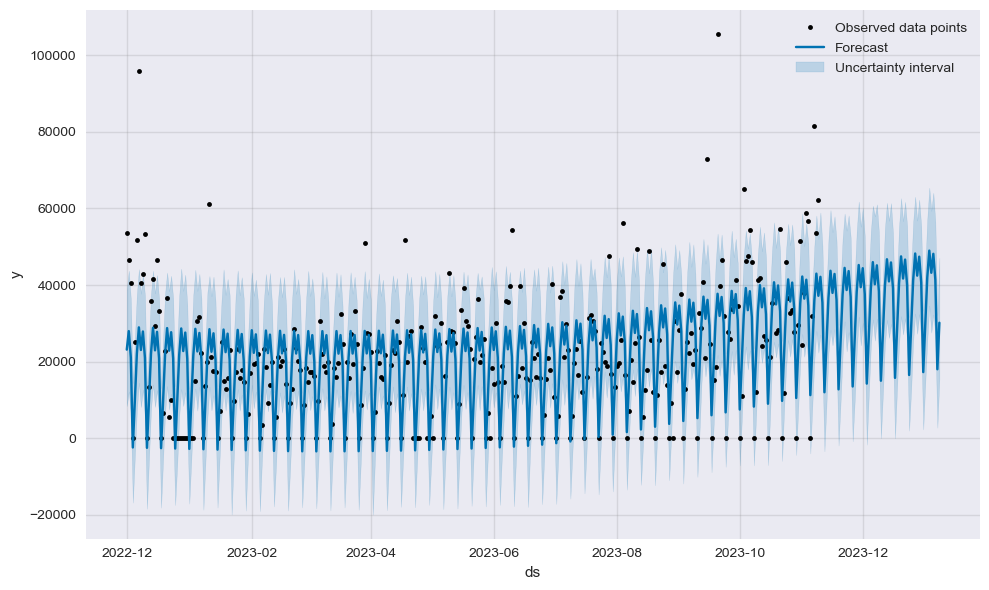

In [1022]:
# Representar los resultados del modelo Prophet:

plot_forecast = plot(model_p_uk, forecast_p_uk, include_legend=True)

En el gráfico anterior se representa la predicción del modelo (línea azul) junto con su intervalo de incertidumbre (sombreado azul claro). Este intervalo indica el rango dentro del cual se espera que se encuentren las ventas reales.
- Se observa que algunos puntos de la serie real quedan fuera de este intervalo, lo que indica la presencia de valores atípicos o picos de demanda puntuales que el modelo no es capaz de predecir.
- En cuanto a la proyección del mes futuro, sigue la tendencia de la serie y la estacionalidad. 

Ahora vamos a analizar este modelo según la estacionalidad aditiva o multiplicativa.

In [1023]:
# Concatenar datasets para comparar in-and-out samples

px.line(pd.concat([df_prophet_uk.set_index('ds')['y'], forecast_p_uk.set_index('ds')['yhat']], axis = 1), title = 'Proyecciones con Prophet | Estacionalidad aditiva')

El modelo vemos que se va adaptando a la serie temporal, sin embargo no predice bien los valores de los domingos, ni tampoco la última tercera parte de la serie. 

Ahora, vamos a comprobar como se comporta Prophet si en vez de analizar la estacionalidad aditiva, analizamos la **estacionalidad multiplicativa.** 

In [1024]:
m_pax_mul = Prophet(seasonality_mode='multiplicative') # aquí indicamos que la estacionalidad sea multiplicativa.
m_pax_mul.fit(df_prophet_uk)

23:57:01 - cmdstanpy - INFO - Chain [1] start processing
23:57:01 - cmdstanpy - INFO - Chain [1] done processing


In [1025]:
future_pax_mul = m_pax_mul.make_future_dataframe(30, freq='D')
display(future_pax_mul.head(10))
display(future_pax_mul.tail(10))

,ds
0,2022-12-01
1,2022-12-02
2,2022-12-03
3,2022-12-04
4,2022-12-05
5,2022-12-06
6,2022-12-07
7,2022-12-08
8,2022-12-09
9,2022-12-10


,ds
394,2023-12-30
395,2023-12-31
396,2024-01-01
397,2024-01-02
398,2024-01-03
399,2024-01-04
400,2024-01-05
401,2024-01-06
402,2024-01-07
403,2024-01-08


In [1026]:
forecast_pax_mul = m_pax_mul.predict(future_pax_mul)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
px.line(pd.concat([df_prophet_uk.set_index('ds')['y'], forecast_pax_mul.set_index('ds')['yhat']], axis = 1), title = 'Proyecciones con Prophet - Estacionalidad multiplicativa')

Este modelo predice mejor que el anterior (estacionalidad aditiva), ya que predice bien los domingos y también predice la tendencia de la serie.

### Métricas de error para Prophet
Es necesario conocer la precisión de nuestro modelo (model_p_uk), para ello vamos a analizar métricas de error como: 
- **Error absoluto medio (MAE)**
- **Error cuadrático medio (MSE)**
- **MAPE**

In [1027]:
# Paso previo
# En forecast_p_uk del model_p_uk, tenemos: train, test y el mes futuro. 
# Para el análisis de error necesito las prediciones de Test
forecast_p_uk_test = forecast_p_uk[['ds','yhat']].iloc[len(train_df_uk):len(train_df_uk)+len(test_df_uk)]

In [1028]:
mae_p_test = round(mean_absolute_error(test_df_uk['y'], forecast_p_uk_test['yhat']),4)
rmse_p_test = round(np.sqrt(mean_squared_error(test_df_uk['y'], forecast_p_uk_test['yhat'])),4)
mape_p_test = round(mean_absolute_percentage_error(test_df_uk['y'], forecast_p_uk_test['yhat']),4)

print('Métricas de evaluación de la parte de test del Modelo Prophet:')
print("  - MAE Prophet:", mae_p_test)
print("  - RMSE Prophet:", rmse_p_test)
print("  - MAPE Prophet:", mape_p_test)

Métricas de evaluación de la parte de test del Modelo Prophet:
  - MAE Prophet: 13957.3909
  - RMSE Prophet: 19517.3631
  - MAPE Prophet: 7.874636911039104e+18


Existe un error muy grande en el MAPE, esto puede deberse a que los domingos estan igualados a 0 en la serie. Voy a intentar solucionar este fallo:

In [1029]:
# Alinear las series que le voy a pasar a MAPE.
y_true = test_df_uk['y'].values
y_pred = forecast_p_uk_test['yhat'].values

In [1030]:
mae_p_test = round(mean_absolute_error(test_df_uk['y'], forecast_p_uk_test['yhat']),4)
rmse_p_test = round(np.sqrt(mean_squared_error(test_df_uk['y'], forecast_p_uk_test['yhat'])),4)
mape_p_test = round(mean_absolute_percentage_error(y_true[y_true!=0], y_pred[y_true!=0]),4) # elimino los valores que tienen 0.

print('Métricas de evaluación de la parte de test del Modelo Prophet:')
print("  - MAE Prophet:", mae_p_test)
print("  - RMSE Prophet:", rmse_p_test)
print("  - MAPE Prophet:", mape_p_test)

Métricas de evaluación de la parte de test del Modelo Prophet:
  - MAE Prophet: 13957.3909
  - RMSE Prophet: 19517.3631
  - MAPE Prophet: 0.2494


Las métricas de evaluación obtenidas para el modelo Prophet muestran un error absoluto medio (MAE) de aproximadamente 13.957. Es decir el modelo se equivoca en 13.517 libras al día. El error cuadrático medio (RMSE) suele penalizar más los errores grandes por eso mayor: 19.517 libras.
Por último,el error porcentual absoluto medio (MAPE) se sitúa en 24.94%, lo que indica que las predicciones del modelo se desvían  un 25% respecto a los valores reales en el conjunto de test.

## 2.1. SARIMAX
Una vez analizado un modelo Prophet, vamos a probar con los modelos ARIMA. Los modelos ARIMA se pueden usar tanto para hacer pronósticos como para comprender mejor los datos. Para datos no estacionarios, los valores en el model ARIMA (p, d, q) representan:
+ p: Número de observaciones de retraso incluidas en el modelo, también llamado orden de retraso
+ d: Número de veces que se diferencian las observaciones sin procesar, también llamado grado de diferenciación.
+ q: Tamaño de la ventana del promedio móvil, también llamado orden del promedio móvil.
En caso de tener datos estacionales, también debemos aplicar las diferencias estacionales. En este caso el modelo ARIMA se expresa como SARIMA e incluye un componente estacional (P, D, Q)

In [1031]:
df_arima_uk = df_uk[['Date','TotalSales']].rename(columns={'Date':'ds','TotalSales':'y'})
df_arima_uk.head()

,ds,y
0,2022-12-01,53520.58
1,2022-12-02,46422.64
2,2022-12-03,40483.46
3,2022-12-04,0.00
4,2022-12-05,25018.63


In [1032]:
# Definimos explícitamente la frecuencia del índice (diario)
df_arima_uk.index.freq = 'D'

In [1033]:
px.line(df_arima_uk['y'])

Como ya hemos visto, esta serie tiene tendencia y estacionalidad, además tiene una tendencia en el tiempo lo que sugiere que los datos no son estacionarios. Vamos a comprobar si es estacionaria a través del Test Dickey-Fuller:

In [1034]:
result_adf_pass = adfuller(df_arima_uk['y'])
dict(zip(['adf', 'pvalue', 'usedlag', 'nobs', 'critical' 'values', 'icbest'], result_adf_pass))

{'adf': np.float64(-1.9874589022182407),
 'pvalue': np.float64(0.2920988607921476),
 'usedlag': 13,
 'nobs': 360,
 'criticalvalues': {'1%': np.float64(-3.448645946352023),
  '5%': np.float64(-2.869602139060357),
  '10%': np.float64(-2.5710650077160495)},
 'icbest': np.float64(7733.408533823692)}

 - Pvalue = 0.29, no está por debajo de 0,05, por tanto la serie no es estacionara. Es necesario **corregir la estacionaridad**. Para ello necesitamos diferenciar el valor de nuestra serie de tiempo: restar la observación anterior de la observación actual.

### - Tratamiento de la estacionaridad
- diferencia(T) = observación(T) — observación(T-1)



In [1035]:
df_arima_uk['diff_pass'] = df_arima_uk['y'] - df_arima_uk['y'].shift(1) # usa 1 por defecto
df_arima_uk.head()

,ds,y,diff_pass
0,2022-12-01,53520.58,NaN
1,2022-12-02,46422.64,-7097.94
2,2022-12-03,40483.46,-5939.18
3,2022-12-04,0.00,-40483.46
4,2022-12-05,25018.63,25018.63


In [1036]:
# Gráfico de la serie diferenciada (es la misma serie que antes, pero sin la tendencia)

px.line(df_arima_uk['diff_pass'])

La serie parece un poco más estacionaria que antes, lo confirmamos con el test de Dickey-Fuller:

In [1037]:
result_diff_pass = adfuller(df_arima_uk['diff_pass'].dropna())
dict(zip(['adf', 'pvalue', 'usedlag', 'nobs', 'critical' 'values', 'icbest'], result_diff_pass))

{'adf': np.float64(-8.055582295902802),
 'pvalue': np.float64(1.6960855614680901e-12),
 'usedlag': 12,
 'nobs': 360,
 'criticalvalues': {'1%': np.float64(-3.448645946352023),
  '5%': np.float64(-2.869602139060357),
  '10%': np.float64(-2.5710650077160495)},
 'icbest': np.float64(7714.84196783757)}

Ahora, p value = 1,69e-12, por tanto, es inferior a 0,05, por lo que podemos rechazar la hipótesis nula. Esto significa que la primera diferencia es estacionaria y sugiere que el componente diferencial **d = 1**.

### - Tratamiento de la estacionalidad 

Por lo gráficos de ACF y PACF se observa la presencia de un patrón estacional. En este caso, al tratarse de ventas diarias, la estacionalidad es semanal (= 7 días).
Para eliminar este componente estacional y facilitar el modelado mediante SARIMA, se puede aplicar una diferenciación estacional
+ diferencia estacional (T) = observación (T) - observación (T-7)
+ primera diferencia estacional (T) = diferencia estacional (T) - diferencia estacional (T-1)

In [1038]:
# diferenciacion 7 días para eliminar esa componente estacional.
df_arima_uk['seas_diff'] = df_arima_uk['y'] - df_arima_uk['y'].shift(7) 

In [1039]:
px.line(df_arima_uk['seas_diff'])

In [1040]:
result_diff_estacional = adfuller((df_arima_uk['seas_diff']).dropna())
dict(zip(['adf', 'pvalue', 'usedlag', 'nobs', 'critical' 'values', 'icbest'], result_diff_estacional))

{'adf': np.float64(-7.141748876930366),
 'pvalue': np.float64(3.310386989251881e-10),
 'usedlag': 13,
 'nobs': 353,
 'criticalvalues': {'1%': np.float64(-3.4490114443793214),
  '5%': np.float64(-2.8697627072503757),
  '10%': np.float64(-2.5711506161673716)},
 'icbest': np.float64(7575.119296662388)}

El p-value es 3.31e-10, por tanto, inferior a 0,05. Se rechaza la hipótesis nula del test de Dickey-Fuller. Por tanto, la serie es  estacionaria despues de la diferenciación, por lo que: **D = 1**


### - Test de Autocorrelación
Antes de hacer el modelo ARIMA es necesario crear los gráficos de autocorrelación y autocorrelación parcial para ayudarnos a estimar los parámetros **p, q, P y Q**.

Podemos crear gráficos para la segunda diferencia y la diferencia estacional de nuestra series temporal porque éstas son las series estacionarias que hemos obtenido (**d = 1, D = 1**).

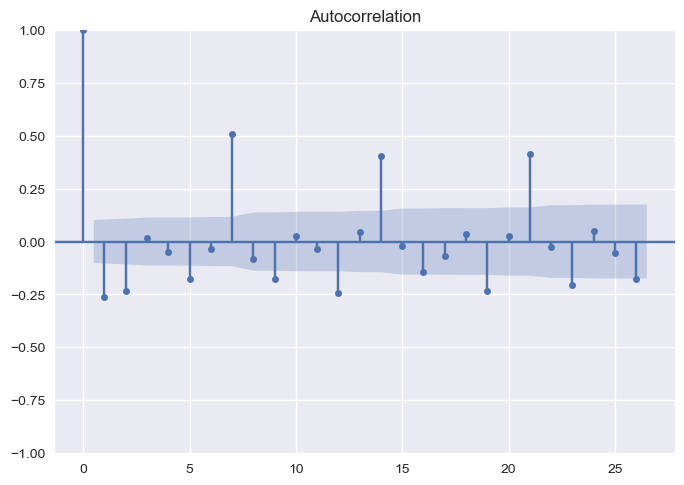

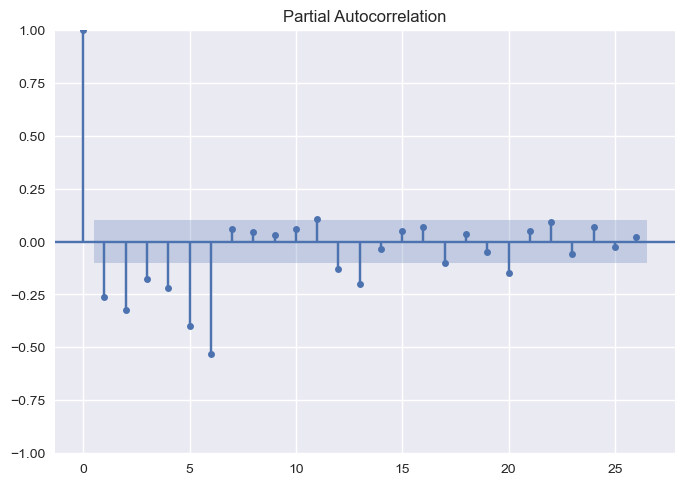

In [1041]:
arima_uk_acf = plot_acf(df_arima_uk['diff_pass'].dropna())
arima_uk_pacf = plot_pacf(df_arima_uk['diff_pass'].dropna())

- En los gráfico de autocorrelación (ACF) se observan varios puntos significativos, como en el punto 7, 14, lo que parece indicar un patrón semanal en la serie. 
- En los gráfico de autocorrelación parcial (PACF), se observa que en la primera semana hay muchos puntos fuera del sombreado, pero luego se adaptan a sombreado, es decir, presenta un corte en el punto 7. 
Este patrón es característico de un modelo autoregresivo (AR) por lo que se va a considerar valores pequeños para p, por ejemplo: **p =1.**

### Ajuste del modelo
 Tenemos una disminución gradual en el gráfico de autocorrelación y un corte en el gráfico de autocorrelación parcial. Esto sugiere utilizar **AR** y no exceder el valor de 1 para la parte estacional del ARIMA.

Los valores que hemos elegido pueden no ser óptimos y es posible que se deban probar diferentes valores para ajustar el modelo.

Vamos a probar el modelo

In [1042]:
df_arima_uk.head() # dataset con dos columnas de más: diff_pass y seas_diff

,ds,y,diff_pass,seas_diff
0,2022-12-01,53520.58,NaN,NaN
1,2022-12-02,46422.64,-7097.94,NaN
2,2022-12-03,40483.46,-5939.18,NaN
3,2022-12-04,0.00,-40483.46,NaN
4,2022-12-05,25018.63,25018.63,NaN


In [1043]:
# Limpiamos el dataset para quedarnos con las variables que realmente nos interesan para la estimación: ds e y

df_arima_uk = df_arima_uk[['ds', 'y']]

In [1044]:
# Fija la fecha como índice: evita warnings en SARIMAX() y viene bien para almacenar las predicciones
df_arima_uk.set_index('ds', inplace = True)
df_arima_uk.index.freq = 'D'
df_arima_uk.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 374 entries, 2022-12-01 to 2023-12-09
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       374 non-null    float64
dtypes: float64(1)
memory usage: 5.8 KB


In [1045]:
df_arima_uk # df limpio.

,y
ds,
2022-12-01,53520.58
2022-12-02,46422.64
2022-12-03,40483.46
2022-12-04,0.00
2022-12-05,25018.63
...,...
2023-12-05,83274.82
2023-12-06,51767.13
2023-12-07,54270.50


In [1046]:
# Estima el modelo SARIMAX
model_arima_uk = SARIMAX(df_arima_uk['y'],
                    order=(1,1,1), # orden de la serie
                    seasonal_order=(1, 0, 1, 7) # orden estacional
                    )
result_arima_uk = model_arima_uk.fit()
result_arima_uk.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                  374
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood               -4048.050
Date:                           Mon, 09 Mar 2026   AIC                           8106.100
Time:                                   23:57:02   BIC                           8125.707
Sample:                               12-01-2022   HQIC                          8113.886
                                    - 12-09-2023                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0564      0.064      0.882      0.378      -0.069       0.182
ma.L1         -0.8631      0.033    -25.998      0.000      -0.928      -0.798
ar.S.L7        0.9924      0.005    193.825      0.000       0.982       1.002
ma.S.L7       -0.8793      0.026    -34.277      0.000      -0.930      -0.829
sigma2      1.518e+08   1.94e-10   7.81e+17      0.000    1.52e+08    1.52e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               877.91
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):               1.75   Skew:                             1.67
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.05e+33. Standard errors may be unstable.
"""

### Análisis del modelo ARIMAX

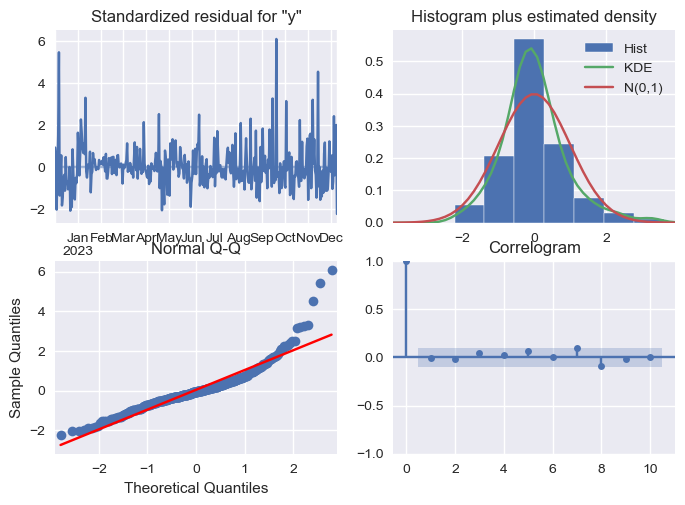

In [1047]:
result_arima_uk.plot_diagnostics()
plt.show()

Para que el modelo SARIMA sea adecuado, los residuos deben ser residuo blanco. Esto quiere decir que no debe presentar autocorrelación, tendencia ni estacionalidad, ya que fue capturada por el modelo.
Al analizar las gráficas anteriores, vemos que se observa residuos que todavía presentan cierta correlación por lo que, indica que el modelo no es bueno y es necesario ajustar los parámetros. 

In [1048]:
# Reajuste del modelo 
# Estima el modelo
model_arima_uk2 = SARIMAX(df_arima_uk['y'],
                    order=(2,1,2), # orden de la serie
                    seasonal_order=(1, 1, 1, 7) # orden estacional
                    )
result_arima_uk2 = model_arima_uk2.fit()
result_arima_uk2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  374
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 7)   Log Likelihood               -3974.759
Date:                             Mon, 09 Mar 2026   AIC                           7963.517
Time:                                     23:57:03   BIC                           7990.836
Sample:                                 12-01-2022   HQIC                          7974.373
                                      - 12-09-2023                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2864      0.752      0.381      0.703      -1.188       1.761
ar.L2         -0.1091      0.115     -0.948      0.343      -0.335       0.116
ma.L1         -1.0136      0.747     -1.356      0.175      -2.478       0.451
ma.L2          0.2703      0.530      0.510      0.610      -0.768       1.308
ar.S.L7        0.0873      0.085      1.023      0.306      -0.080       0.255
ma.S.L7       -0.8733      0.047    -18.508      0.000      -0.966      -0.781
sigma2      2.175e+08   1.31e-08   1.65e+16      0.000    2.17e+08    2.17e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.14   Jarque-Bera (JB):               438.66
Prob(Q):                              0.71   Prob(JB):                         0.00
Heteroskedasticity (H):               2.32   Skew:                             1.16
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.84
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 5.58e+32. Standard errors may be unstable.
"""

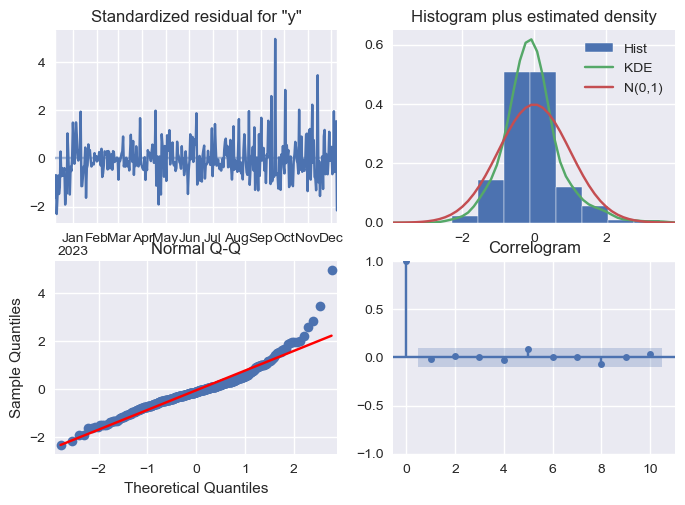

In [1049]:
result_arima_uk2.plot_diagnostics()
plt.show()

Para elegir el mejor modelo posible de Sarimax, existe la funcion *auto_arima* que elige la mejor combinación posible para este modelo:

In [1050]:
# Para escoger el mejor modelo ARIMA, realizamos la siguiente función:

auto_arima_pax = auto_arima(train_df_uk['y'],
                       start_P=1,
                       start_q=1,
                       max_p=7,
                       max_q=7,
                       m=7,
                       seasonal=True,
                       D=0,
                       max_d = 3,
                       trace=True,
                       error_action='ignore',
                       suppress_warnings=True,
                       stepwise=True)
auto_arima_pax.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,1)(1,0,1)[7] intercept   : AIC=7495.227, Time=0.48 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=7725.317, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=7614.494, Time=0.04 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=7569.837, Time=0.48 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=7723.320, Time=0.00 sec
 ARIMA(2,1,1)(0,0,1)[7] intercept   : AIC=7554.783, Time=0.11 sec
 ARIMA(2,1,1)(1,0,0)[7] intercept   : AIC=7539.816, Time=0.09 sec
 ARIMA(2,1,1)(2,0,1)[7] intercept   : AIC=7496.795, Time=0.82 sec
 ARIMA(2,1,1)(1,0,2)[7] intercept   : AIC=7516.229, Time=0.52 sec
 ARIMA(2,1,1)(0,0,0)[7] intercept   : AIC=7594.770, Time=0.02 sec
 ARIMA(2,1,1)(0,0,2)[7] intercept   : AIC=7543.422, Time=0.29 sec
 ARIMA(2,1,1)(2,0,0)[7] intercept   : AIC=7529.249, Time=0.20 sec
 ARIMA(2,1,1)(2,0,2)[7] intercept   : AIC=inf, Time=1.90 sec
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=7497.394, Time=0.38 sec
 ARIMA(2,1,0)(1,0,1)[7] intercept   : 

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  344
Model:             SARIMAX(2, 1, 2)x(1, 0, [1], 7)   Log Likelihood               -3712.281
Date:                             Mon, 09 Mar 2026   AIC                           7440.563
Time:                                     23:57:35   BIC                           7471.265
Sample:                                          0   HQIC                          7452.792
                                             - 344                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.2858      4.316     -0.066      0.947      -8.746       8.174
ar.L1         -0.7563      0.389     -1.942      0.052      -1.520       0.007
ar.L2         -0.0089      0.115     -0.077      0.939      -0.234       0.216
ma.L1         -0.0105      0.386     -0.027      0.978      -0.767       0.746
ma.L2         -0.6504      0.338     -1.925      0.054      -1.313       0.012
ar.S.L7        0.9959      0.006    177.327      0.000       0.985       1.007
ma.S.L7       -0.9319      0.044    -21.313      0.000      -1.018      -0.846
sigma2      1.747e+08   9.83e-07   1.78e+14      0.000    1.75e+08    1.75e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):               859.66
Prob(Q):                              0.87   Prob(JB):                         0.00
Heteroskedasticity (H):               1.52   Skew:                             1.65
Prob(H) (two-sided):                  0.03   Kurtosis:                        10.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 8.04e+28. Standard errors may be unstable.
"""

In [1051]:
model_auto = SARIMAX(train_df_uk['y'],order=(2, 1, 2),
              seasonal_order=(1, 0, 1, 7),
              enforce_stationarity=False,
              enforce_invertibility=False)
results_auto_arima = model_auto.fit()
results_auto_arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  344
Model:             SARIMAX(2, 1, 2)x(1, 0, [1], 7)   Log Likelihood               -3591.371
Date:                             Mon, 09 Mar 2026   AIC                           7196.741
Time:                                     23:57:36   BIC                           7223.398
Sample:                                          0   HQIC                          7207.371
                                             - 344                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1735      0.366     -0.474      0.635      -0.890       0.543
ar.L2         -0.1842      0.099     -1.862      0.063      -0.378       0.010
ma.L1         -0.5747      0.352     -1.631      0.103      -1.265       0.116
ma.L2          0.0196      0.257      0.076      0.939      -0.485       0.524
ar.S.L7        1.0041      0.016     63.752      0.000       0.973       1.035
ma.S.L7       -0.8332      0.040    -20.715      0.000      -0.912      -0.754
sigma2      1.748e+08   4.03e-09   4.33e+16      0.000    1.75e+08    1.75e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.20   Jarque-Bera (JB):               607.11
Prob(Q):                              0.66   Prob(JB):                         0.00
Heteroskedasticity (H):               2.19   Skew:                             1.32
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.07
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.8e+32. Standard errors may be unstable.
"""

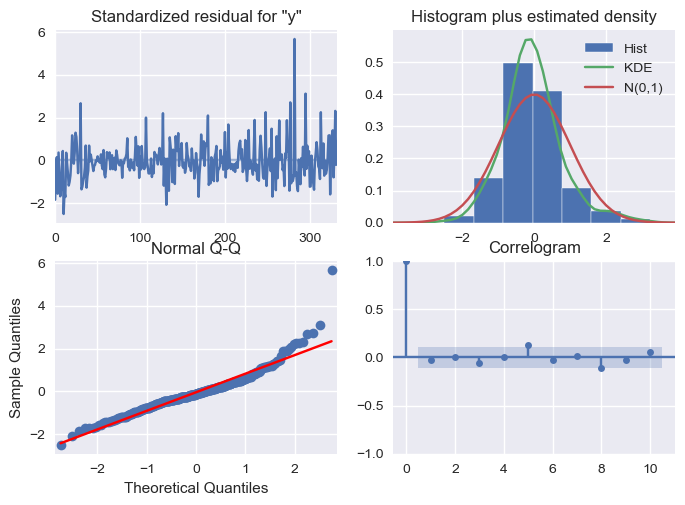

In [1052]:
dignostics_auto = results_auto_arima.plot_diagnostics()

In [1053]:
# Comparación de los 3 modelos SARIMAX utilizados:
print(f'El AIC del primer modelo SARIMAX (1,1,1)(1,0,1,7) fue de {(result_arima_uk.aic)}')
print(f'El AIC del segundo modelo SARIMAX (2,1,2)(1,1,1,7) fue de {(result_arima_uk2.aic)}')
print(f'El AIC del modelo SARIMAX auto-ARIMA (2,1,2)(1,0,1,7) fue de {(results_auto_arima.aic)}')

El AIC del primer modelo SARIMAX (1,1,1)(1,0,1,7) fue de 8106.099578005674
El AIC del segundo modelo SARIMAX (2,1,2)(1,1,1,7) fue de 7963.517236085202
El AIC del modelo SARIMAX auto-ARIMA (2,1,2)(1,0,1,7) fue de 7196.741015541758


### Modelo SARIMAX con Train y Test:

In [1054]:
test_df_uk.tail()

,ds,y
369,2023-12-05,83274.82
370,2023-12-06,51767.13
371,2023-12-07,54270.50
372,2023-12-08,77242.10
373,2023-12-09,26956.27


In [1055]:
# Modelo SARIMAX con Train y Test:
model_arima_uk3 =  SARIMAX(train_df_uk['y'], order=(2,1,2),seasonal_order=(1,1,1,7))
result_arima_uk3 = model_arima_uk3.fit()
result_arima_uk3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  344
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 7)   Log Likelihood               -3635.394
Date:                             Mon, 09 Mar 2026   AIC                           7284.789
Time:                                     23:57:37   BIC                           7311.509
Sample:                                          0   HQIC                          7295.440
                                             - 344                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3464      0.543      0.639      0.523      -0.717       1.410
ar.L2         -0.1693      0.120     -1.408      0.159      -0.405       0.066
ma.L1         -1.0401      0.538     -1.933      0.053      -2.095       0.014
ma.L2          0.3455      0.365      0.946      0.344      -0.370       1.061
ar.S.L7        0.0940      0.088      1.067      0.286      -0.079       0.267
ma.S.L7       -0.9223      0.052    -17.879      0.000      -1.023      -0.821
sigma2      2.048e+08   4.42e-09   4.63e+16      0.000    2.05e+08    2.05e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.20   Jarque-Bera (JB):               502.38
Prob(Q):                              0.66   Prob(JB):                         0.00
Heteroskedasticity (H):               2.08   Skew:                             1.21
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.48
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.72e+32. Standard errors may be unstable.
"""

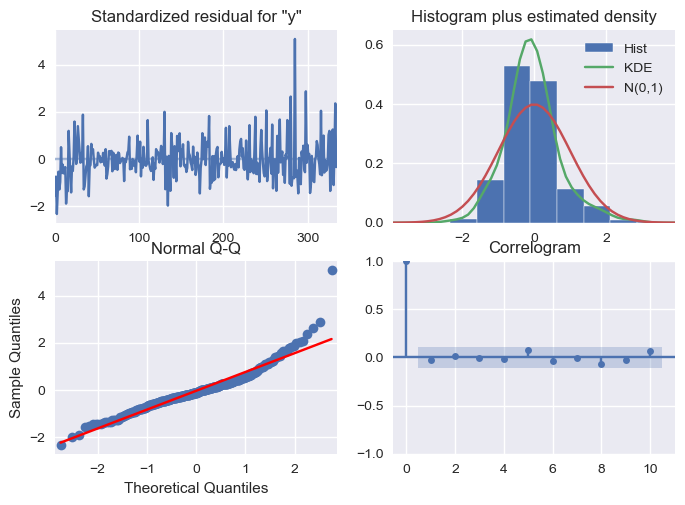

In [1056]:
result_arima_uk3.plot_diagnostics()
plt.show()

In [1057]:
print(f'El AIC del modelo SARIMAX (2,1,2)(1,1,1,7) fue de {(result_arima_uk3.aic)}')

El AIC del modelo SARIMAX (2,1,2)(1,1,1,7) fue de 7284.788792559477


In [1058]:
# Produce 30 predicciones correspondientes a los 30 días del test
forecast_s_uk_test = results_auto_arima.forecast(steps=len(test_df_uk))

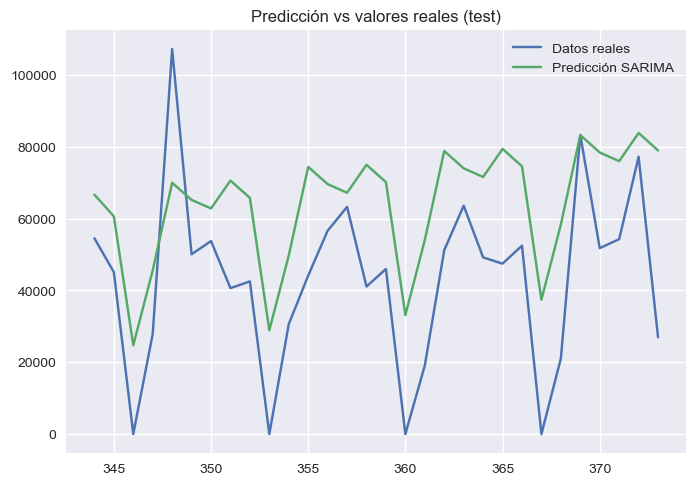

In [1059]:
plt.figure()

plt.plot(test_df_uk['y'], label="Datos reales")
plt.plot(test_df_uk.index, forecast_s_uk_test, label="Predicción SARIMA")

plt.legend()
plt.title("Predicción vs valores reales (test)")
plt.show()

In [1060]:
# Evaluar métricas para SARIMAX:

mae_s_test = round(mean_absolute_error(test_df_uk['y'], forecast_s_uk_test),4)
rmse_s_test = round(np.sqrt(mean_squared_error(test_df_uk['y'], forecast_s_uk_test)),4)
mape_s_test = round(mean_absolute_percentage_error(test_df_uk['y'], forecast_s_uk_test),4)

print('Métricas de evaluación de la parte de test del Modelo SARIMAX:')
print("  - MAE SARIMAX:", mae_s_test)
print("  - RMSE SARIMAX:", rmse_s_test)
print("  - MAPE SARIMAX:", mape_s_test)

Métricas de evaluación de la parte de test del Modelo SARIMAX:
  - MAE SARIMAX: 23415.6135
  - RMSE SARIMAX: 26086.4778
  - MAPE SARIMAX: 1.863577829207006e+19


Con respecto al MAE y al RMSE existe un erro r de 23415 libras y 26086 libras, lo cual es más alto que el error del modelo Prophet.

Existe un error altísimo en MAPE, como ocurría con el modelo Prophet, esto puede ser debido a que imputé todas las fechas faltantes (porque los domingos no hay ventas) a 0. Vamos a intentar corregirlo:

In [1061]:
# Alinear las series que le voy a pasar a MAPE.
y_true_s = test_df_uk['y'].values
y_pred_s = forecast_s_uk_test.values

In [1062]:
mask = test_df_uk['y'] != 0
mape_s_test = round(mean_absolute_percentage_error(test_df_uk['y'][mask], forecast_s_uk_test[mask]),4)


print('Métricas de evaluación de la parte de test del Modelo SARIMAX:')
print("  - MAE SARIMAX:", mae_s_test)
print("  - RMSE SARIMAX:", rmse_s_test)
print("  - MAPE SARIMAX:", mape_s_test)

Métricas de evaluación de la parte de test del Modelo SARIMAX:
  - MAE SARIMAX: 23415.6135
  - RMSE SARIMAX: 26086.4778
  - MAPE SARIMAX: 0.5789


## 3. Análisis de Resultados y Selección de Modelo.   
### 3.1. Comparación de modelos.  


In [1063]:
resultados = pd.DataFrame({
    "Modelo":[model_p_uk,model_arima_uk3], #Modelo Prophet - Modelo SARIMAX
              "MAE":[mape_p_test,mae_s_test],
              "RMS":[rmse_p_test,rmse_s_test],
              "MAPE":[mape_p_test,mape_s_test]
})
resultados

,Modelo,MAE,RMS,MAPE
0,<prophet.forecaster.Prophet object at 0x3256fe...,0.2494,19517.3631,0.2494
1,<statsmodels.tsa.statespace.sarimax.SARIMAX ob...,23415.6135,26086.4778,0.5789


In [1064]:
# Comparación de resultados de ambos modelos: Prophet y SARIMAX

print('Métricas de evaluación de la parte de test del Modelo Prophet:')
print("  - MAE Prophet:", mae_p_test)
print("  - RMSE Prophet:", rmse_p_test)
print("  - MAPE Prophet:", mape_p_test) # mape suele ser la métrica ás intuitiva porque mide el error porcentual.
print( )
print('Métricas de evaluación de la parte de test del Modelo SARIMAX:')
print("  - MAE SARIMAX:", mae_s_test)
print("  - RMSE SARIMAX:", rmse_s_test)
print("  - MAPE SARIMAX:", mape_s_test)

Métricas de evaluación de la parte de test del Modelo Prophet:
  - MAE Prophet: 13957.3909
  - RMSE Prophet: 19517.3631
  - MAPE Prophet: 0.2494

Métricas de evaluación de la parte de test del Modelo SARIMAX:
  - MAE SARIMAX: 23415.6135
  - RMSE SARIMAX: 26086.4778
  - MAPE SARIMAX: 0.5789


### 3.2. Selección de modelo basada en criterios y métricas. 

En base a las métricas anteriores, se elige el modelo Prophet por tener un MAPE bastante más pequeño (0.24) frente al MAPE de SARIMAX (0.57)

### 3.3. Predicciones para el próximo mes - utilizando Prophet
A continuación vamos a utilizar el modelo Prophet, el cual ya hemos comprobado que predice mejor. Vamos a entrenarlo con todo el dataset disponible (hasta el último dato de 9 de diciembre de 2023), e intentaremos predecir el mes siguiente: del 9 de diciembre de 2023 hasta el 8 de enero de 2024. 

In [1065]:
display(df_prophet_uk)

,ds,y
0,2022-12-01,53520.58
1,2022-12-02,46422.64
2,2022-12-03,40483.46
3,2022-12-04,0.00
4,2022-12-05,25018.63
...,...,...
369,2023-12-05,83274.82
370,2023-12-06,51767.13
371,2023-12-07,54270.50
372,2023-12-08,77242.10


In [1066]:
# Entrenar el modelo con todo el dataset

m = Prophet(weekly_seasonality=True, daily_seasonality=False)
m.fit(df_prophet_uk)

23:57:37 - cmdstanpy - INFO - Chain [1] start processing
23:57:37 - cmdstanpy - INFO - Chain [1] done processing


In [1071]:
# Proyectar a un mes vista (del 9/12/2023 al 8/01/2024)

future_df = m.make_future_dataframe(periods=30, freq='D') # predecir un mes más
future_df
future_df.tail() # compruebo que ha añadido 30 días más

,ds
399,2024-01-04
400,2024-01-05
401,2024-01-06
402,2024-01-07
403,2024-01-08


In [1068]:
# Generar las predicciones: ds = fecha, yhat = dicción, yhat_lower = límite inferior, yhat_upper = límite superior.
forecast_df = m.predict(future_df)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

display(forecast_df.head(5))
display(forecast_df.tail(5))

,ds,yhat,yhat_lower,yhat_upper
0,2022-12-01,25145.278916,10391.037394,42252.839762
1,2022-12-02,29529.912572,13993.372877,44886.445055
2,2022-12-03,22343.375397,5717.174045,38347.148353
3,2022-12-04,-2610.268483,-19343.156820,12285.745650
4,2022-12-05,10291.436879,-5224.463492,27095.351024


,ds,yhat,yhat_lower,yhat_upper
399,2024-01-04,51074.535000,36022.810621,66788.541744
400,2024-01-05,55675.886643,39578.948909,71932.269571
401,2024-01-06,48706.067453,32429.609493,63820.132393
402,2024-01-07,23969.141559,7531.157792,39371.772755
403,2024-01-08,37087.564907,22213.372855,53296.236337


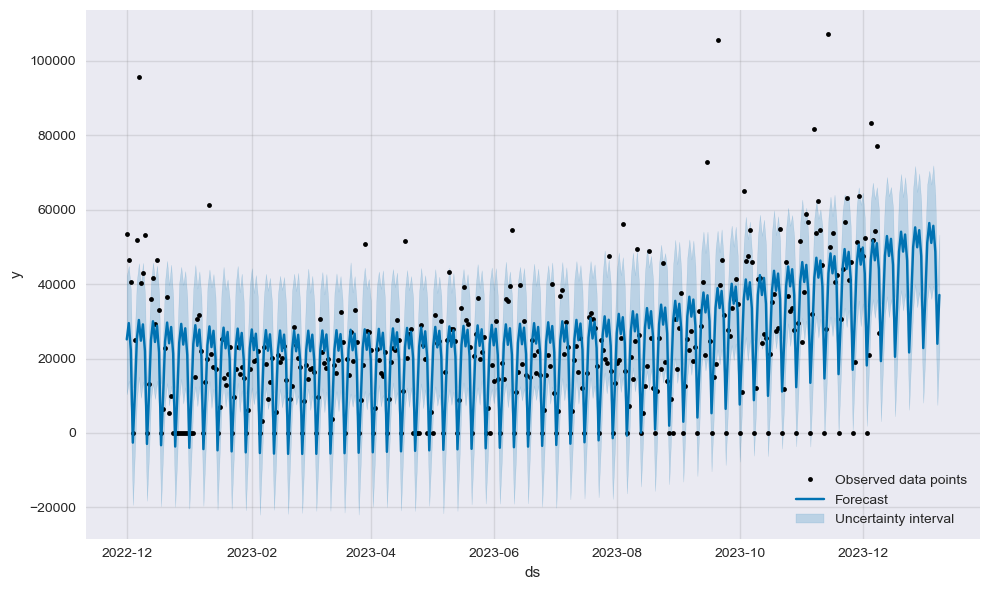

In [1069]:
# Representar los resultados del modelo Prophet:
plot_forecast = plot(m, forecast_df, include_legend=True)

El modelo seleccionado permite proyectar la evolución esperada de las ventas durante el próximo mes, desde el 9 de diciembre de 2023 hasta el 8 de enero de 2024. 
- Las predicciones muestran una continuidad en la tendencia observada en los últimos meses (tendencia positiva), manteniendo además el patrón semanal. 
- El modelo predice que las ventas continuarán con tendencia ascendente y con fluctuaciones recurrentes entre los distintos días de la semana. El modelo predice que pueden alcanzarse picos de hasta 50.000 ventas.  

Estas estimaciones permiten anticipar el comportamiento esperado de las ventas a corto plazo y pueden servir como apoyo para la planificación comercial (gestión del inventario o de personal, control de stock) y la toma de decisiones estratégicas, como el lanzamiento de campañas promociones.

## Conclusiones
Este estudio se centró en encontrar un modelo con buena capacidad de predicción de las ventas futuras de la empresa *Todo Ventas, S.A.*. El análisis se centró en Reino Unido por presentar una serie temporal mucho más completa y con mayor volumen que el resto de países.

Una vez validado el modelo para Reino Unido, podría aplicarse el mismo procedimiento al resto de países.
